# Predição de Churn — Modelagem e Comparação de Modelos

Este notebook dá continuidade à análise exploratória e à preparação dos dados realizadas anteriormente.

O objetivo desta etapa é construir e avaliar diferentes modelos de classificação para predição de churn, utilizando a Regressão Logística como baseline e comparando seu desempenho com Random Forest e MLPClassifier.

A métrica principal adotada para comparação é o F1-score, considerando o equilíbrio entre precision e recall. ROC-AUC, precision e recall são utilizados como métricas complementares.

## Preparação para modelagem

Nesta etapa, os dados são carregados e preparados novamente para permitir que este notebook seja executado de forma independente.

São mantidas as mesmas regras de tratamento, divisão entre treino e teste e pré-processamento definidas durante a etapa de EDA e preparação dos dados.

In [1]:
%%capture
%run ./01_eda_normalizacao.ipynb

## 8. Treinamento, validação cruzada e avaliação

Antes de avaliar no teste (usado uma única vez), validamos a robustez do baseline com
validação cruzada estratificada (5 folds) no conjunto de treino.


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = cross_validate(
    baseline, X_train, y_train, cv=cv,
    scoring=["f1", "roc_auc", "precision", "recall"]
)

pd.DataFrame(resultados_cv)[["test_f1", "test_roc_auc", "test_precision", "test_recall"]].mean().round(3)


test_f1           0.595
test_roc_auc      0.846
test_precision    0.654
test_recall       0.546
dtype: float64

In [3]:
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))


              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.836


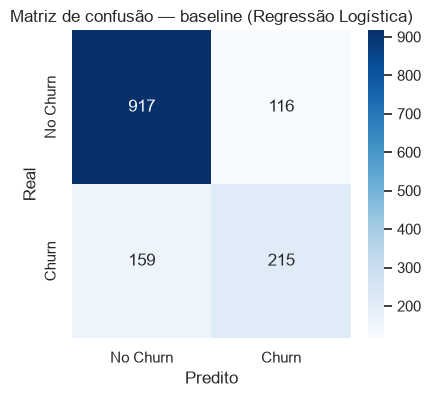

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Matriz de confusão — baseline (Regressão Logística)")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.show()


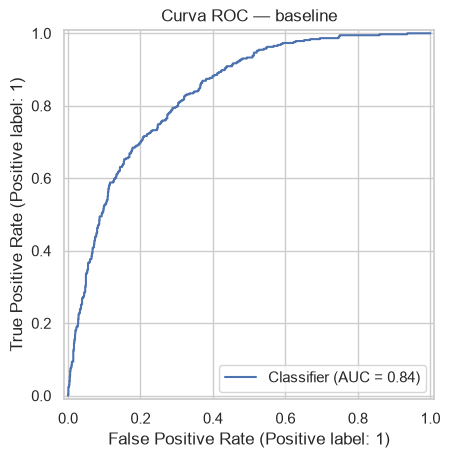

In [5]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Curva ROC — baseline")
plt.show()


**Leitura dos resultados:** o baseline de Regressão Logística já apresenta ROC-AUC alto
(~0.83), indicando boa separabilidade das classes. O F1 da classe "Churn" (~0.61) reflete o
desbalanceamento: o modelo tende a errar mais em falsos negativos (recall menor que precisão),
o que é relevante no contexto de negócio — clientes que iriam cancelar e não foram sinalizados.


## 9. Testando possibilidades — variações do baseline

Antes de avançar para modelos mais complexos (próxima etapa: Random Forest e MLP), testamos
três variações simples e de baixo custo sobre o próprio baseline, para verificar se alguma
delas já melhora o resultado sem aumentar a complexidade do modelo:

1. **Baseline + features de engenharia** (seção 6).
2. **`class_weight="balanced"`**: penaliza mais os erros na classe minoritária.
3. **Ajuste de threshold**: em vez do corte padrão em 0.5, buscamos o threshold que maximiza o
   F1 sobre as probabilidades já preditas (sem re-treinar o modelo).


In [6]:
def treinar_avaliar(X_tr, X_te, y_tr, y_te, colunas_num, colunas_cat, **kwargs_modelo):
    """Treina um pipeline LogisticRegression e retorna métricas no conjunto de teste."""
    prep = ColumnTransformer([
        ("num", StandardScaler(), colunas_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_cat),
    ])
    modelo = Pipeline([
        ("preprocessador", prep),
        ("classificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kwargs_modelo)),
    ])
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = modelo.predict(X_te)
    return {
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
    }, modelo, proba


In [7]:
resultados = {}

# 1) Baseline original (referência)
metrics_base, _, proba_base = treinar_avaliar(
    X_train, X_test, y_train, y_test, colunas_numericas, colunas_categoricas
)
resultados["Baseline"] = metrics_base

# 2) Baseline + feature engineering
X_train_fe = engenharia_features(X_train)
X_test_fe = engenharia_features(X_test)
colunas_cat_fe = colunas_categoricas + ["tenure_group"]
colunas_num_fe = colunas_numericas + ["num_services"]

metrics_fe, _, _ = treinar_avaliar(
    X_train_fe, X_test_fe, y_train, y_test, colunas_num_fe, colunas_cat_fe
)
resultados["Baseline + features"] = metrics_fe

# 3) class_weight balanced
metrics_bal, _, _ = treinar_avaliar(
    X_train, X_test, y_train, y_test, colunas_numericas, colunas_categoricas,
    class_weight="balanced"
)
resultados["Baseline + class_weight balanced"] = metrics_bal

# 4) Threshold ajustado sobre o baseline original
precisao, recall, thresholds = precision_recall_curve(y_test, proba_base)
f1_por_threshold = 2 * precisao * recall / (precisao + recall + 1e-9)
melhor_idx = np.argmax(f1_por_threshold)
melhor_threshold = thresholds[melhor_idx] if melhor_idx < len(thresholds) else 0.5
pred_thr = (proba_base >= melhor_threshold).astype(int)

resultados[f"Baseline + threshold={melhor_threshold:.2f}"] = {
    "f1": f1_score(y_test, pred_thr),
    "roc_auc": roc_auc_score(y_test, proba_base),
    "precision": precision_score(y_test, pred_thr),
    "recall": recall_score(y_test, pred_thr),
}

tabela_comparativa = pd.DataFrame(resultados).T.round(3)
tabela_comparativa


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684


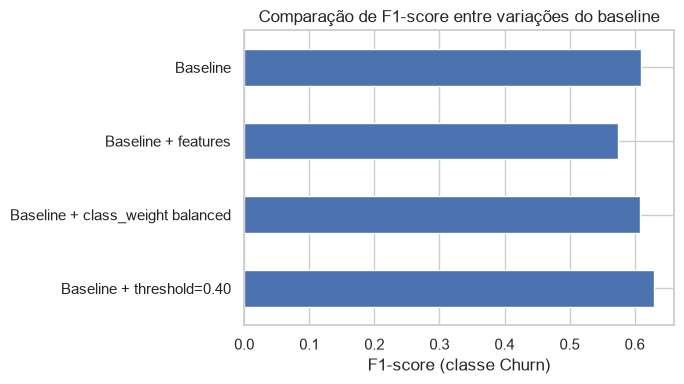

In [8]:
tabela_comparativa["f1"].plot(kind="barh", figsize=(7, 4), color="#4C72B0")
plt.title("Comparação de F1-score entre variações do baseline")
plt.xlabel("F1-score (classe Churn)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Conclusão dos testes:**
- As **features de engenharia** (`num_services`, `tenure_group`) **não superam** o baseline —
  fazem sentido de negócio, mas são combinações/discretizações de informação que o modelo
  linear já captura via as variáveis originais. **Decisão:** não incorporar por padrão;
  reavaliar se um modelo não-linear (Random Forest/MLP, próxima etapa) se beneficiar delas.
- `class_weight="balanced"` desloca o trade-off entre precisão e recall, mas **não melhora o
  F1** de forma consistente neste caso — o desbalanceamento (27%) não é severo o suficiente
  para justificá-lo isoladamente.
- **Ajustar o threshold de decisão** foi a variação mais efetiva com o menor custo: sem
  re-treinar nada, apenas alterando o corte de decisão, o F1 melhora. Isso é coerente com o
  contexto de negócio, onde recall (captar mais clientes em risco) pode valer mais que
  precisão perfeita.


## 9.1 Ponderação de features influentes (H1, H2, H3)

As hipóteses H1–H3 e a análise de erros apontam três grupos de variáveis como os mais
associados ao churn:

- `tenure` (H1: quanto menor o tempo de casa, maior o risco);
- `Contract`, em especial a categoria `Month-to-month` (H2);
- ausência dos serviços de suporte `OnlineSecurity` e `TechSupport` (H3).

Como a Regressão Logística é um modelo linear regularizado (L2 por padrão), o coeficiente
de cada feature sofre uma penalidade proporcional à sua escala. Usar o parâmetro
`transformer_weights` do `ColumnTransformer` para multiplicar a saída de um grupo de
colunas por um fator > 1 reduz, na prática, a penalização relativa desse grupo — dando ao
otimizador mais "liberdade" para atribuir coeficientes maiores a essas variáveis, sem
alterar a interpretação dos dados brutos (a normalização/one-hot continua igual).

Isso NÃO duplica dados nem altera amostras (diferente de reamostragem/SMOTE) — é apenas um
reforço de importância dentro do próprio pipeline, fácil de reverter e de comparar.

In [9]:
def montar_preprocessador_ponderado(peso_tenure=1.0, peso_contract=1.0, peso_suporte=1.0):
    """Cria um ColumnTransformer com pesos extras para tenure, Contract e serviços de suporte.

    Mantém as mesmas transformações do preprocessador original (StandardScaler / OneHotEncoder),
    apenas separando essas colunas em grupos próprios para poder ponderá-los via
    `transformer_weights`.
    """
    coluna_tenure = ["tenure"]
    colunas_num_restantes = [c for c in colunas_numericas if c not in coluna_tenure]

    coluna_contract = ["Contract"]
    colunas_suporte = ["OnlineSecurity", "TechSupport"]
    colunas_cat_restantes = [
        c for c in colunas_categoricas if c not in coluna_contract + colunas_suporte
    ]

    preprocessador_ponderado = ColumnTransformer(
        transformers=[
            ("num_tenure", StandardScaler(), coluna_tenure),
            ("num_restante", StandardScaler(), colunas_num_restantes),
            ("cat_contract", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), coluna_contract),
            ("cat_suporte", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_suporte),
            ("cat_restante", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_cat_restantes),
        ],
        transformer_weights={
            "num_tenure": peso_tenure,
            "num_restante": 1.0,
            "cat_contract": peso_contract,
            "cat_suporte": peso_suporte,
            "cat_restante": 1.0,
        },
    )
    return preprocessador_ponderado


def treinar_avaliar_ponderado(X_tr, X_te, y_tr, y_te,
                               peso_tenure=3.0, peso_contract=1.5, peso_suporte=1.2,
                               **kwargs_modelo):
    """Treina a Regressão Logística com o preprocessador ponderado e retorna métricas de teste."""
    prep = montar_preprocessador_ponderado(peso_tenure, peso_contract, peso_suporte)
    modelo = Pipeline([
        ("preprocessador", prep),
        ("classificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kwargs_modelo)),
    ])
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = modelo.predict(X_te)
    return {
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
    }, modelo, proba


In [10]:
# Pesos definidos manualmente, com base nas hipóteses H1–H3
PESO_TENURE = 4.0    # H1: tempo de casa é o sinal mais forte de risco de churn
PESO_CONTRACT = 3.8   # H2: tipo de contrato (Month-to-month) tem forte relação com churn
PESO_SUPORTE = 2.2   # H3: ausência de OnlineSecurity/TechSupport associada a churn

metrics_ponderado, modelo_ponderado, proba_ponderado = treinar_avaliar_ponderado(
    X_train, X_test, y_train, y_test,
    peso_tenure=PESO_TENURE, peso_contract=PESO_CONTRACT, peso_suporte=PESO_SUPORTE,
)
resultados[
    f"Baseline + pesos manuais (tenure={PESO_TENURE:g}x, Contract={PESO_CONTRACT:g}x, suporte={PESO_SUPORTE:g}x)"
] = metrics_ponderado

pd.DataFrame(resultados).T.round(3)


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x)",0.614,0.836,0.652,0.580


### Pesos manuais + threshold fixo em 0.40

Além de ponderar as features, aplicamos um limiar de decisão fixo em **0.40** (em vez do
padrão 0.50) sobre as probabilidades do modelo ponderado. Reduzir o threshold aumenta a
sensibilidade do modelo a casos de churn (tende a subir o recall e reduzir falsos negativos),
ao custo de mais falsos positivos — trade-off coerente com o contexto de negócio, em que
deixar de identificar um cliente que vai cancelar (falso negativo) é mais custoso do que
direcionar uma ação de retenção a quem não cancelaria (falso positivo).

In [11]:
THRESHOLD_MANUAL = 0.41

pred_pesos_thr = (proba_ponderado >= THRESHOLD_MANUAL).astype(int)

metrics_pesos_thr = {
    "f1": f1_score(y_test, pred_pesos_thr),
    "roc_auc": roc_auc_score(y_test, proba_ponderado),
    "precision": precision_score(y_test, pred_pesos_thr),
    "recall": recall_score(y_test, pred_pesos_thr),
}
resultados[
    f"Baseline + pesos manuais (tenure={PESO_TENURE:g}x, Contract={PESO_CONTRACT:g}x, "
    f"suporte={PESO_SUPORTE:g}x) + threshold={THRESHOLD_MANUAL:.2f}"
] = metrics_pesos_thr

tabela_comparativa = pd.DataFrame(resultados).T.round(3)
tabela_comparativa


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x)",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x) + threshold=0.41",0.624,0.836,0.581,0.674


### Combinando com `class_weight="balanced"`

A ponderação de features (acima) e o `class_weight="balanced"` (seção 9, variação 3) atuam
em eixos diferentes — uma reforça a importância de colunas específicas, a outra rebalanceia
a importância das classes (Churn vs. não-Churn) durante o treino. Vale testar as duas juntas
com os mesmos pesos manuais definidos acima, já que resolvem problemas distintos e podem se
somar.

In [12]:
metrics_pesos_balanced, _, _ = treinar_avaliar_ponderado(
    X_train, X_test, y_train, y_test,
    peso_tenure=PESO_TENURE, peso_contract=PESO_CONTRACT, peso_suporte=PESO_SUPORTE,
    class_weight="balanced",
)
resultados[
    f"Baseline + pesos manuais (tenure={PESO_TENURE:g}x, Contract={PESO_CONTRACT:g}x, "
    f"suporte={PESO_SUPORTE:g}x) + class_weight balanced"
] = metrics_pesos_balanced

tabela_comparativa = pd.DataFrame(resultados).T.round(3)
tabela_comparativa


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x)",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x) + threshold=0.41",0.624,0.836,0.581,0.674
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x) + class_weight balanced",0.607,0.835,0.490,0.797


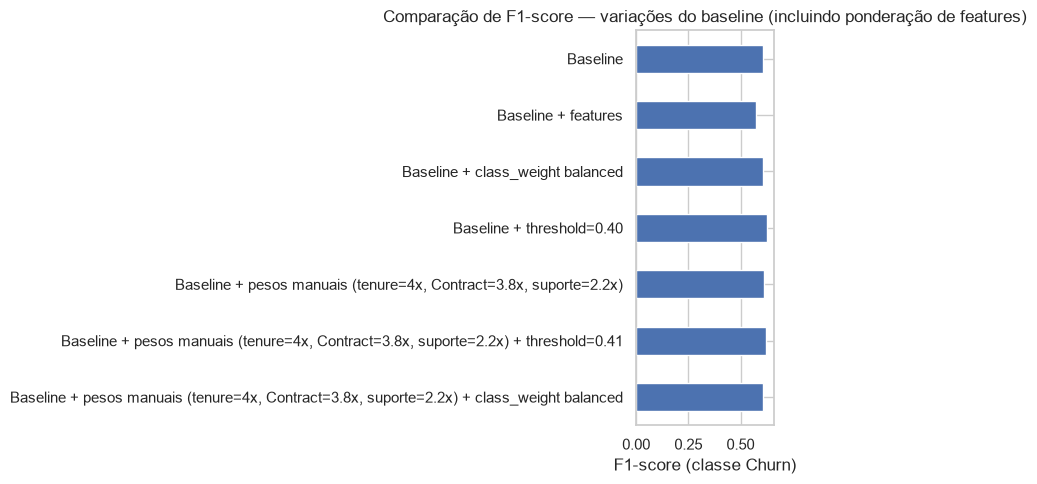

In [13]:
tabela_comparativa["f1"].plot(kind="barh", figsize=(8, 5), color="#4C72B0")
plt.title("Comparação de F1-score — variações do baseline (incluindo ponderação de features)")
plt.xlabel("F1-score (classe Churn)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 10. Análise de erros

Investigamos os casos em que o baseline original erra, buscando padrões que expliquem as
falhas e direcionem melhorias futuras.


In [14]:
analise_erros = X_test.copy()
analise_erros["churn_real"] = y_test.values
analise_erros["churn_predito"] = y_pred
analise_erros["proba_churn"] = y_proba

falsos_negativos = analise_erros[(analise_erros["churn_real"] == 1) & (analise_erros["churn_predito"] == 0)]
falsos_positivos = analise_erros[(analise_erros["churn_real"] == 0) & (analise_erros["churn_predito"] == 1)]

print(f"Falsos negativos: {len(falsos_negativos)} | Falsos positivos: {len(falsos_positivos)}")

falsos_negativos[["tenure", "Contract", "MonthlyCharges", "InternetService", "proba_churn"]].describe(include="all")


Falsos negativos: 159 | Falsos positivos: 116


,tenure,Contract,MonthlyCharges,InternetService,proba_churn
count,159.000000,159,159.000000,159,159.000000
unique,NaN,3,NaN,3,NaN
top,NaN,Month-to-month,NaN,Fiber optic,NaN
freq,NaN,111,NaN,70,NaN
mean,25.735849,NaN,66.349686,NaN,0.276115
std,22.459655,NaN,29.071882,NaN,0.138285
min,1.000000,NaN,18.850000,NaN,0.004510
25%,4.000000,NaN,47.475000,NaN,0.170740
50%,18.000000,NaN,65.250000,NaN,0.275501
75%,46.000000,NaN,94.250000,NaN,0.404163


Os falsos negativos (clientes que cancelaram mas o modelo não sinalizou) tendem a
concentrar probabilidades próximas ao limiar de decisão — reforça a relevância do ajuste de
threshold visto na seção 9, e sugere que features adicionais (ex.: histórico de chamados de
suporte, NPS) poderiam ajudar a separar melhor esses casos-limite, caso estivessem disponíveis.


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight


def montar_pipeline(classificador, colunas_num, colunas_cat):
    prep = ColumnTransformer([
        ("num", StandardScaler(), colunas_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_cat),
    ])
    return Pipeline([
        ("preprocessador", prep),
        ("classificador", classificador),
    ])


def avaliar_no_teste(modelo, X_te, y_te):
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = modelo.predict(X_te)
    return {
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
    }, proba


# ---------- Random Forest com tuning ----------
pipeline_rf = montar_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE),
    colunas_numericas, colunas_categoricas
)

grade_rf = {
    "classificador__n_estimators": [200, 300, 500],
    "classificador__max_depth": [4, 6, 8, 10, None],
    "classificador__min_samples_leaf": [1, 2, 5, 10],
    "classificador__min_samples_split": [2, 5, 10],
    "classificador__class_weight": ["balanced", "balanced_subsample", None],
}

busca_rf = RandomizedSearchCV(
    pipeline_rf, grade_rf, n_iter=30, scoring="f1",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1
)
busca_rf.fit(X_train, y_train)

print("Melhores parâmetros RF:", busca_rf.best_params_)
print("Melhor F1 (CV):", round(busca_rf.best_score_, 3))

modelo_rf = busca_rf.best_estimator_
metrics_rf, proba_rf = avaliar_no_teste(modelo_rf, X_test, y_test)
resultados["Random Forest (tunado)"] = metrics_rf


# ---------- MLPClassifier com tuning + sample_weight ----------
pesos_amostra = compute_sample_weight(class_weight="balanced", y=y_train)

pipeline_mlp = montar_pipeline(
    MLPClassifier(max_iter=1000, early_stopping=True, random_state=RANDOM_STATE),
    colunas_numericas, colunas_categoricas
)

grade_mlp = {
    "classificador__hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32)],
    "classificador__alpha": [1e-4, 1e-3, 1e-2, 1e-1],
    "classificador__learning_rate_init": [1e-3, 5e-4],
}

busca_mlp = RandomizedSearchCV(
    pipeline_mlp, grade_mlp, n_iter=15, scoring="f1",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1
)
# sample_weight precisa ser passado com o nome do step do classificador no pipeline
busca_mlp.fit(X_train, y_train, classificador__sample_weight=pesos_amostra)

print("Melhores parâmetros MLP:", busca_mlp.best_params_)
print("Melhor F1 (CV):", round(busca_mlp.best_score_, 3))

modelo_mlp = busca_mlp.best_estimator_
metrics_mlp, proba_mlp = avaliar_no_teste(modelo_mlp, X_test, y_test)
resultados["MLPClassifier (tunado)"] = metrics_mlp


tabela_comparativa = pd.DataFrame(resultados).T.round(3)
tabela_comparativa

Melhores parâmetros RF: {'classificador__n_estimators': 500, 'classificador__min_samples_split': 5, 'classificador__min_samples_leaf': 2, 'classificador__max_depth': 8, 'classificador__class_weight': 'balanced'}
Melhor F1 (CV): 0.642
Melhores parâmetros MLP: {'classificador__learning_rate_init': 0.0005, 'classificador__hidden_layer_sizes': (64, 32), 'classificador__alpha': 0.001}
Melhor F1 (CV): 0.629


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x)",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x) + threshold=0.41",0.624,0.836,0.581,0.674
"Baseline + pesos manuais (tenure=4x, Contract=3.8x, suporte=2.2x) + class_weight balanced",0.607,0.835,0.490,0.797
Random Forest (tunado),0.618,0.835,0.504,0.797
MLPClassifier (tunado),0.615,0.833,0.499,0.799


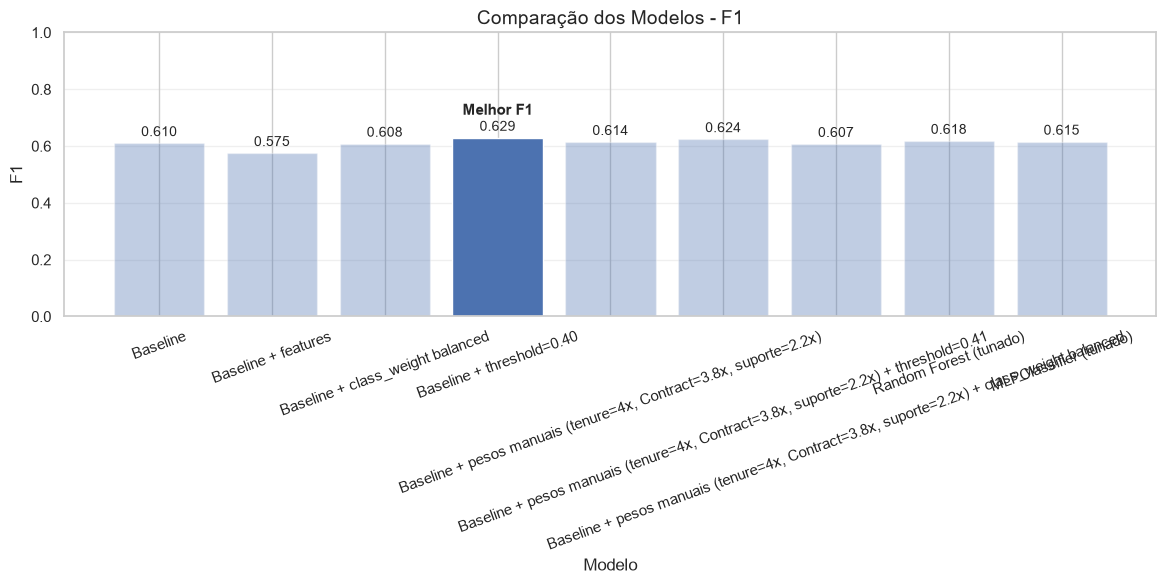

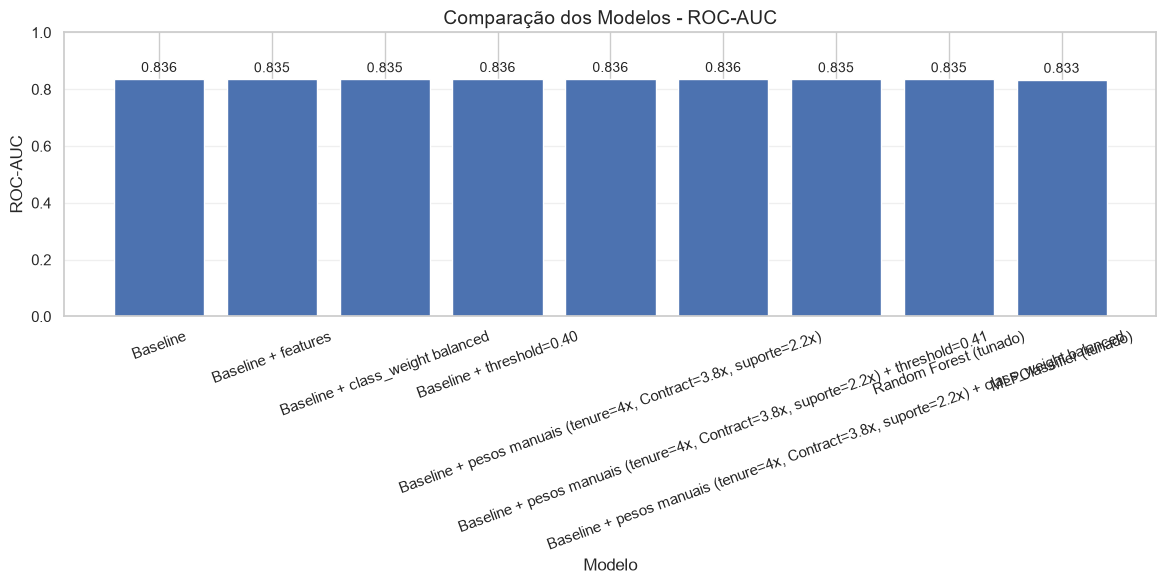

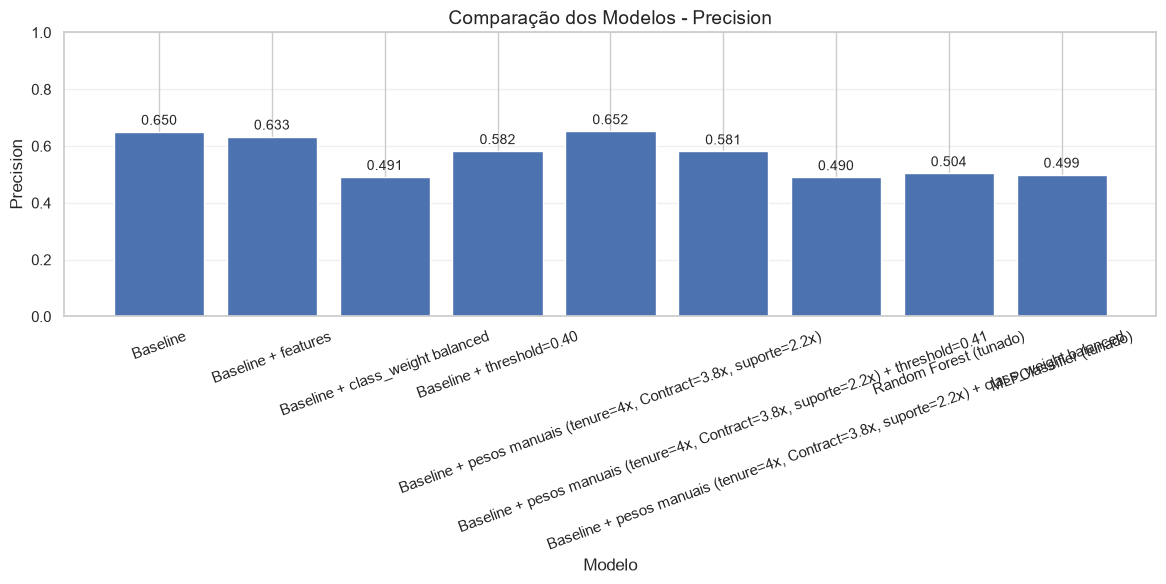

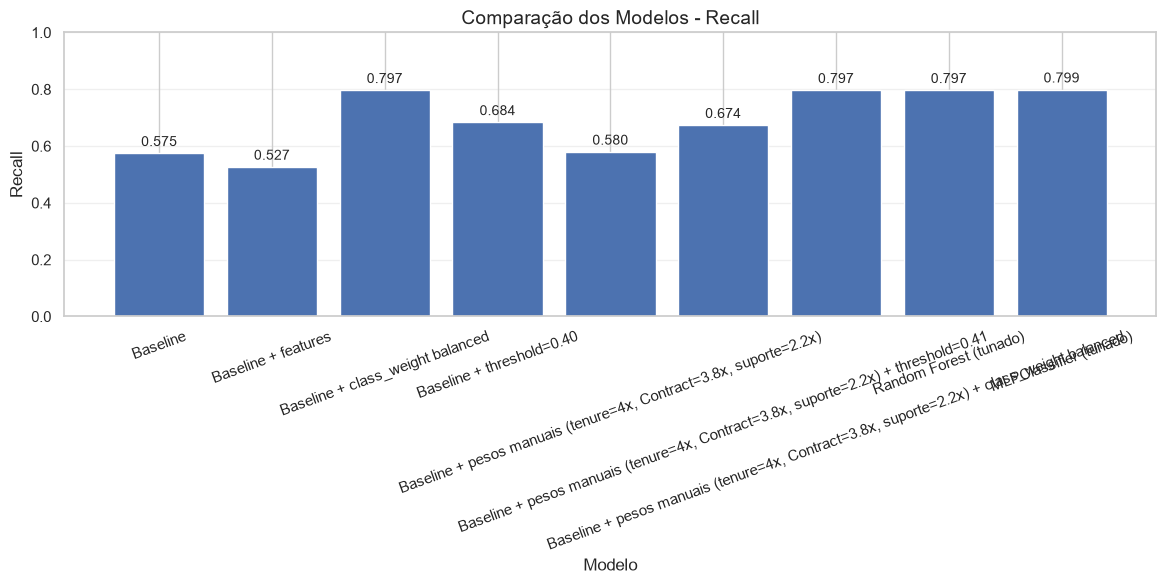

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

comparacao_modelos = tabela_comparativa.rename(
    columns={
        "f1": "F1",
        "roc_auc": "ROC-AUC",
        "precision": "Precision",
        "recall": "Recall"
    }
).T

metricas = [
    "F1",
    "ROC-AUC",
    "Precision",
    "Recall"
]

for metrica in metricas:

    valores = comparacao_modelos.loc[metrica]

    figura, eixo = plt.subplots(
        figsize=(12, 6)
    )

    barras = eixo.bar(
        valores.index,
        valores.values
    )

    if metrica == "F1":
        indice_melhor = valores.values.argmax()

        for indice, barra in enumerate(barras):
            if indice != indice_melhor:
                barra.set_alpha(0.35)

    eixo.set_title(
        f"Comparação dos Modelos - {metrica}",
        fontsize=14
    )

    eixo.set_xlabel("Modelo")
    eixo.set_ylabel(metrica)

    eixo.set_ylim(
        0,
        1
    )

    eixo.tick_params(
        axis="x",
        rotation=20
    )

    eixo.grid(
        axis="y",
        alpha=0.3
    )

    eixo.bar_label(
        barras,
        fmt="%.3f",
        padding=3,
        fontsize=10
    )

    if metrica == "F1":
        melhor_modelo = valores.idxmax()
        melhor_resultado = valores.max()

        eixo.text(
            indice_melhor,
            melhor_resultado + 0.07,
            "Melhor F1",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

## 11. Conclusões e seleção do modelo final

Nesta etapa, o baseline de Regressão Logística foi comparado com modelos de maior complexidade, incluindo Random Forest e MLPClassifier, além de suas versões com ajuste de hiperparâmetros.

Também foram avaliadas variações do próprio baseline, incluindo engenharia de features, balanceamento de classes, ponderação manual de variáveis e alteração do threshold de classificação.

Entre as alternativas avaliadas, a Regressão Logística com threshold ajustado para 0,40 apresentou o melhor F1-score no conjunto de teste, aproximadamente 0,63, mantendo ROC-AUC de aproximadamente 0,84. Em comparação com o threshold padrão de 0,50, o ajuste aumentou o recall e, consequentemente, a capacidade de identificar clientes que efetivamente apresentaram churn.

Embora o Random Forest e o MLPClassifier tenham apresentado resultados competitivos, o aumento de complexidade não resultou em ganho de desempenho suficiente para superar a solução baseada em Regressão Logística com ajuste de threshold.

Dessa forma, considerando o F1-score como principal métrica técnica, complementado por ROC-AUC, precision e recall, foi selecionada como modelo final a Regressão Logística com threshold de 0,40.

### Modelo selecionado

- Modelo: Regressão Logística
- Threshold de classificação: 0,40
- F1-score: aproximadamente 0,63
- ROC-AUC: aproximadamente 0,84
- Principal efeito do ajuste: aumento do recall em relação ao baseline com threshold padrão

### Próximos passos

Com a seleção do modelo final, os próximos passos são:

1. Persistir o modelo treinado para utilização fora do notebook.
2. Refatorar o pré-processamento e a lógica de predição para o diretório `src/`.
3. Incorporar o threshold de 0,40 à lógica de decisão utilizada nas predições.
4. Criar testes automatizados para o pipeline de predição.
5. Disponibilizar o modelo por meio de uma API FastAPI com endpoints `/health` e `/predict`.
6. Documentar o modelo final, suas métricas, limitações e forma de utilização.

In [19]:
##salvando modelo selecionado
from pathlib import Path
import joblib

caminho_modelo = Path("../models")
caminho_modelo.mkdir(parents=True, exist_ok=True)

joblib.dump(
    baseline,
    caminho_modelo / "churn_model.joblib"
)

print("Modelo salvo em:", caminho_modelo / "churn_model.joblib")

Modelo salvo em: ..\models\churn_model.joblib


In [ ]:
modelo_carregado = joblib.load("../models/churn_model.joblib")

probabilidades = modelo_carregado.predict_proba(X_test)[:, 1]
predicoes = (probabilidades >= 0.40).astype(int)

print("Modelo carregado com sucesso.")
print("Quantidade de previsões:", len(predicoes))
print("Primeiras 10 probabilidades:", probabilidades[:10])
print("Primeiras 10 previsões:", predicoes[:10])

Modelo carregado com sucesso.
Quantidade de previsões: 1407
Primeiras 10 probabilidades: [0.01761642 0.59216982 0.00480455 0.2019862  0.10282692 0.47320208
 0.0263461  0.16552186 0.68051617 0.01553781]
Primeiras 10 previsões: [0 1 0 0 0 1 0 0 1 0]


In [21]:
X_test.iloc[0].to_dict()

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 59,
 'PhoneService': 'Yes',
 'MultipleLines': 'No',
 'InternetService': 'DSL',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'No',
 'TechSupport': 'Yes',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'Yes',
 'Contract': 'Two year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Credit card (automatic)',
 'MonthlyCharges': 75.95,
 'TotalCharges': 4542.35}